In [81]:
from typing_extensions import TypedDict,Annotated
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv




In [82]:
load_dotenv()

True

In [83]:
def keep_last(existing, new):
    return new
class ParentState(TypedDict):
    question: str
    answer_eng: Annotated[str, keep_last]   # ← handles both subgraphs writing it
    answer_nep: str
    answer_fre: str

class NepaliSubgraphState(TypedDict):
    answer_eng: str
    answer_nep: str

class FrenchSubgraphState(TypedDict):
    answer_eng: str
    answer_fre: str

In [84]:
parent_llm=ChatOpenAI(model='gpt-4o-mini')
subgraph_llm=ChatOpenAI(model='gpt-4o')

In [85]:
# Cell 5 — Node functions
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f'You are a helpful assistant. Answer clearly.\n\nQuestion: {state["question"]}').content
    return {'answer_eng': answer}

def translate_text(state: NepaliSubgraphState):
    prompt = f'''
Translate the following text to Nepali.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
'''.strip()
    return {'answer_nep': subgraph_llm.invoke(prompt).content}

def translate_text2(state: FrenchSubgraphState):
    prompt = f'''
Translate the following text to French.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
'''.strip()
    return {'answer_fre': subgraph_llm.invoke(prompt).content}

In [86]:
# Cell 6 — Build subgraphs
subgraph = StateGraph(NepaliSubgraphState)
subgraph.add_node('translate_text', translate_text)
subgraph.add_edge(START, 'translate_text')
subgraph.add_edge('translate_text', END)
subgraph = subgraph.compile()

In [87]:

subgraph2 = StateGraph(FrenchSubgraphState)
subgraph2.add_node('translate_text2', translate_text2)
subgraph2.add_edge(START, 'translate_text2')
subgraph2.add_edge('translate_text2', END)
subgraph2 = subgraph2.compile()

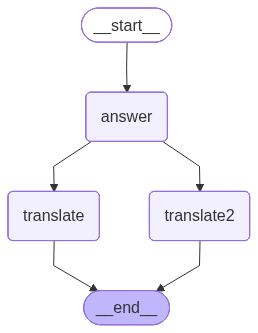

In [88]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('answer', generate_answer)
parent_builder.add_node('translate', subgraph)
parent_builder.add_node('translate2', subgraph2)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('answer', 'translate2')
parent_builder.add_edge('translate', END)
parent_builder.add_edge('translate2', END)
graph = parent_builder.compile()
graph


In [89]:
graph.invoke({'question': 'What is Nihilism'})

{'question': 'What is Nihilism',
 'answer_eng': 'Nihilism is a philosophical belief that suggests that life lacks inherent meaning, value, or purpose. It often reflects a skepticism toward established moral principles and societal norms. Nihilists may assert that there is no objective truth or ultimate significance in human existence. This perspective can manifest in various forms, including existential nihilism, which focuses on the individual and the meaning of life, and moral nihilism, which denies the existence of any moral truths. Nihilism has been explored in literature, art, and philosophy, particularly in the works of Friedrich Nietzsche and other existential thinkers.',
 'answer_nep': 'निहिलिज्म एक दार्शनिक विश्वास हो जसले जीवनमा अन्तर्निहित अर्थ, मूल्य, वा उद्देश्यको अभावलाई सङ्केत गर्दछ। यसले प्राय: स्थापित नैतिक सिद्धान्तहरू र समाजिक मान्यताहरूप्रति शङ्का व्यक्त गर्दछ। निहिलिस्टहरूले मान्न सक्छन् कि मानव अस्तित्वमा कुनै वस्तुगत सत्य वा अन्तिम महत्त्व छैन। यस दृष्टिकोणले विभ